# 04 - transfer learning

## Proyecto
**Clasificación de razas de perros y gatos con CNN y Transfer Learning**  
Dataset: **Oxford-IIIT Pet Dataset**

## Objetivo de este notebook
En este notebook implementaremos la segunda gran iteración del proyecto: un modelo basado en **transfer learning**.

### ¿Qué es transfer learning?
Transfer learning consiste en reutilizar una red neuronal que ya fue entrenada previamente en un problema grande de visión por computador, y adaptarla a una nueva tarea.  
En este caso usaremos **MobileNetV2** preentrenada en **ImageNet** como extractor de características.

### Lo que haremos
1. cargar el dataset,
2. aplicar el preprocesado apropiado para MobileNetV2,
3. construir un modelo con base convolucional preentrenada congelada,
4. añadir una nueva cabeza de clasificación para nuestras 37 clases,
5. entrenar el modelo,
6. evaluar en test,
7. analizar resultados con curvas, reporte de clasificación y matriz de confusión.

> Este notebook implementa una solución más potente que la CNN base y servirá como referencia principal antes del fine-tuning final.

## 1. Importación de librerías

Usaremos:

- **tensorflow**: para construir el modelo y entrenarlo.
- **tensorflow_datasets**: para cargar el Oxford-IIIT Pet Dataset.
- **matplotlib** y **seaborn**: para visualización.
- **numpy**: apoyo numérico.
- **scikit-learn**: para métricas de clasificación.

También fijamos semillas para mejorar la reproducibilidad.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.20.0
TensorFlow Datasets version: 4.9.10


## 2. Carga del dataset

Usaremos la misma partición utilizada en los notebooks anteriores:

- `train[:80%]` para entrenamiento,
- `train[80%:]` para validación,
- `test` para evaluación final.

Esto mantiene consistencia entre experimentos y facilita la comparación con la línea base.

In [2]:
dataset_name = "oxford_iiit_pet"

(train_raw, val_raw, test_raw), info = tfds.load(
    dataset_name,
    split=["train[:80%]", "train[80%:]", "test"],
    with_info=True,
    as_supervised=False
)

class_names = info.features["label"].names
num_classes = info.features["label"].num_classes

print("Número de clases:", num_classes)
print("Train:", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation:", tf.data.experimental.cardinality(val_raw).numpy())
print("Test:", tf.data.experimental.cardinality(test_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Número de clases: 37
Train: 2944
Validation: 736
Test: 3669


## 3. Hiperparámetros

Definimos los valores principales del experimento.

### Variables
- **IMG_SIZE**: tamaño de entrada de las imágenes.
- **BATCH_SIZE**: tamaño del lote.
- **INITIAL_EPOCHS**: número máximo de épocas para esta etapa.
- **LEARNING_RATE**: tasa de aprendizaje inicial.

### Comentario
Usamos `224x224` porque es un tamaño estándar y compatible con MobileNetV2.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000
INITIAL_EPOCHS = 10
LEARNING_RATE = 1e-3

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("INITIAL_EPOCHS:", INITIAL_EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)

IMG_SIZE: (224, 224)
BATCH_SIZE: 32
INITIAL_EPOCHS: 10
LEARNING_RATE: 0.001


## 4. Preprocesado específico para MobileNetV2

A diferencia del baseline, aquí no basta con dividir entre 255.  
MobileNetV2 fue entrenada con un preprocesado particular, por lo que debemos usar la función oficial:

`tf.keras.applications.mobilenet_v2.preprocess_input`

### Pasos del preprocesado
1. convertir la imagen a `float32`,
2. redimensionarla a `224x224`,
3. aplicar el preprocesado oficial de MobileNetV2,
4. devolver `(image, label)`.

In [4]:
def preprocess_example_mobilenet(example, img_size=IMG_SIZE):
    image = example["image"]
    label = example["label"]

    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, img_size)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

## 5. Data augmentation

Aunque MobileNetV2 ya parte de características aprendidas, sigue siendo útil aplicar un aumento de datos moderado en entrenamiento.

Usaremos:
- volteo horizontal,
- pequeña rotación,
- pequeño zoom.

Esto ayuda a que el modelo generalice mejor sin deformar demasiado la imagen.

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

## 6. Construcción del pipeline de datos

Armaremos los datasets con `tf.data` usando:

- `map`,
- `cache`,
- `shuffle`,
- `batch`,
- `prefetch`.

Solo el conjunto de entrenamiento se mezcla.

In [6]:
def build_dataset(ds, training=False):
    ds = ds.map(preprocess_example_mobilenet, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()

    if training:
        ds = ds.shuffle(SHUFFLE_BUFFER, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_raw, training=True)
val_ds = build_dataset(val_raw, training=False)
test_ds = build_dataset(test_raw, training=False)

print("Datasets listos para MobileNetV2.")

Datasets listos para MobileNetV2.


## 7. Verificación del pipeline

Revisamos rápidamente un lote del pipeline para confirmar:

- forma del tensor,
- rango de valores,
- formato correcto de etiquetas.

In [7]:
images_batch, labels_batch = next(iter(train_ds))

print("Shape imágenes:", images_batch.shape)
print("Shape etiquetas:", labels_batch.shape)
print("Tipo de dato:", images_batch.dtype)
print("Valor mínimo:", tf.reduce_min(images_batch).numpy())
print("Valor máximo:", tf.reduce_max(images_batch).numpy())

Shape imágenes: (32, 224, 224, 3)
Shape etiquetas: (32,)
Tipo de dato: <dtype: 'float32'>
Valor mínimo: -1.0
Valor máximo: 1.0


## 8. Visualización de imágenes preprocesadas para MobileNetV2

Como el preprocesado de MobileNetV2 altera el rango de valores, para visualizar correctamente una imagen debemos reescalarla de forma simple al rango `[0, 1]`.

### Nota
Esta reescala es solo para visualización, no para entrenamiento.

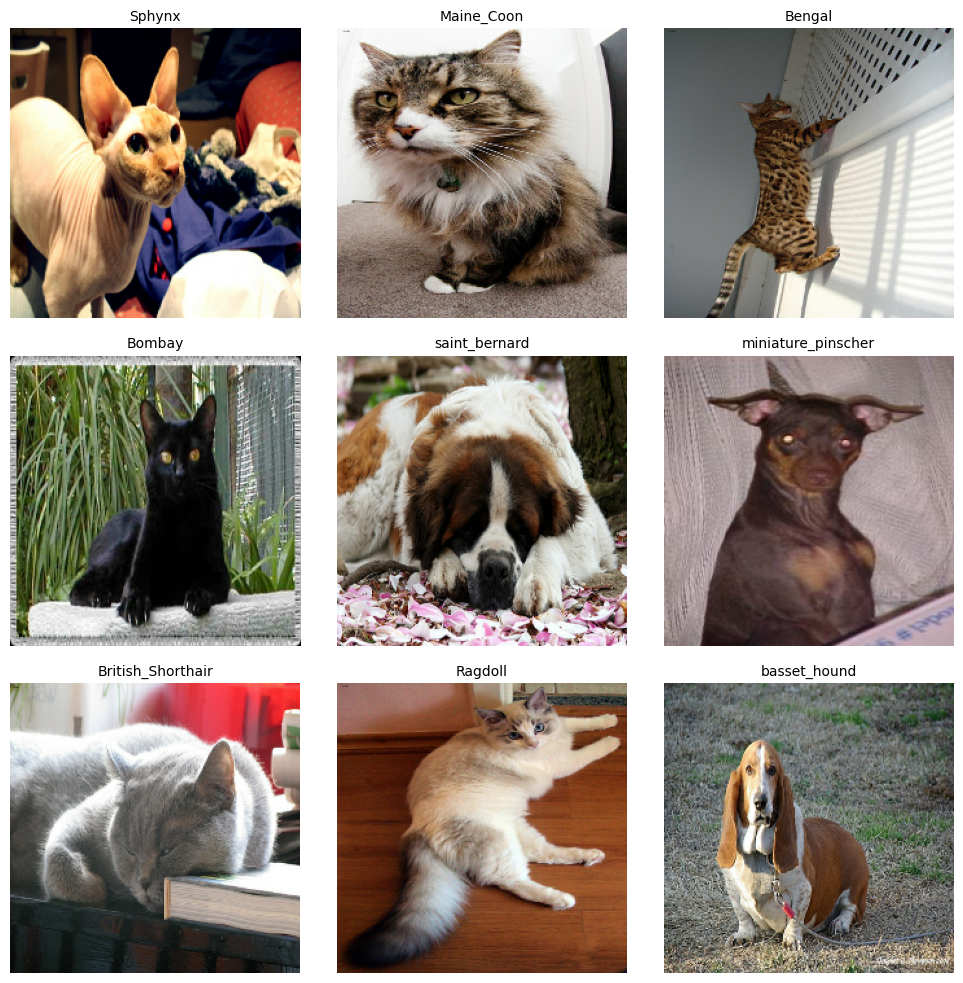

In [8]:
def to_display_range(image):
    image = image.numpy()
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)
    return image

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(to_display_range(images_batch[i]))
    plt.title(class_names[int(labels_batch[i])], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Creación de la base convolucional preentrenada

Aquí cargamos **MobileNetV2** con pesos preentrenados en **ImageNet**.

### Parámetros importantes
- `input_shape=IMG_SIZE + (3,)`: define la forma de entrada.
- `include_top=False`: elimina la cabeza de clasificación original de ImageNet.
- `weights="imagenet"`: carga pesos preentrenados.

### Congelación de la base
En esta primera fase de transfer learning dejaremos la base convolucional congelada:

`base_model.trainable = False`

Esto significa que sus pesos no se actualizarán durante entrenamiento; solo aprenderá la nueva cabeza clasificadora.

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model trainable:", base_model.trainable)
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model trainable: False


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Construcción del modelo de transfer learning

Ahora armamos el modelo completo.

### Estructura
1. capa de entrada,
2. data augmentation,
3. base convolucional MobileNetV2 congelada,
4. `GlobalAveragePooling2D`,
5. `Dropout`,
6. capa final `Dense(num_classes, softmax)`.

### ¿Por qué `training=False` en la base?
Cuando llamamos la base con `training=False`, evitamos actualizar internamente comportamientos como Batch Normalization en esta etapa congelada.

In [10]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")
model.summary()

Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 11. Compilación del modelo

Configuramos el entrenamiento con:

- **Optimizador**: Adam
- **Pérdida**: SparseCategoricalCrossentropy
- **Métrica**: accuracy

Mantenemos una configuración simple y estable para esta fase.

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


## 12. Callbacks

Usaremos:
- **EarlyStopping** para detener el entrenamiento si deja de mejorar,
- **ReduceLROnPlateau** para ajustar el learning rate automáticamente.

Esto suele mejorar estabilidad y evitar sobreentrenamiento innecesario.

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

callbacks

## 13. Entrenamiento del modelo

En esta etapa solo entrenaremos la cabeza de clasificación, mientras MobileNetV2 actúa como extractor de características fijo.

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.5608 - loss: 1.6772 - val_accuracy: 0.8601 - val_loss: 0.6154 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.8305 - loss: 0.5933 - val_accuracy: 0.8736 - val_loss: 0.4439 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8733 - loss: 0.4294 - val_accuracy: 0.8804 - val_loss: 0.3799 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.8889 - loss: 0.3628 - val_accuracy: 0.8886 - val_loss: 0.3604 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9018 - loss: 0.3128 - val_accuracy: 0.8872 - val_loss: 0.3586 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9147 - loss: 0.2676 - val_accuracy: 0.8954 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9310 - loss: 0.2366 - val_acc

## 14. Curvas de entrenamiento

Visualizamos:
- pérdida de entrenamiento y validación,
- accuracy de entrenamiento y validación.

Esto nos ayudará a comparar después con el baseline y con la versión de fine-tuning.

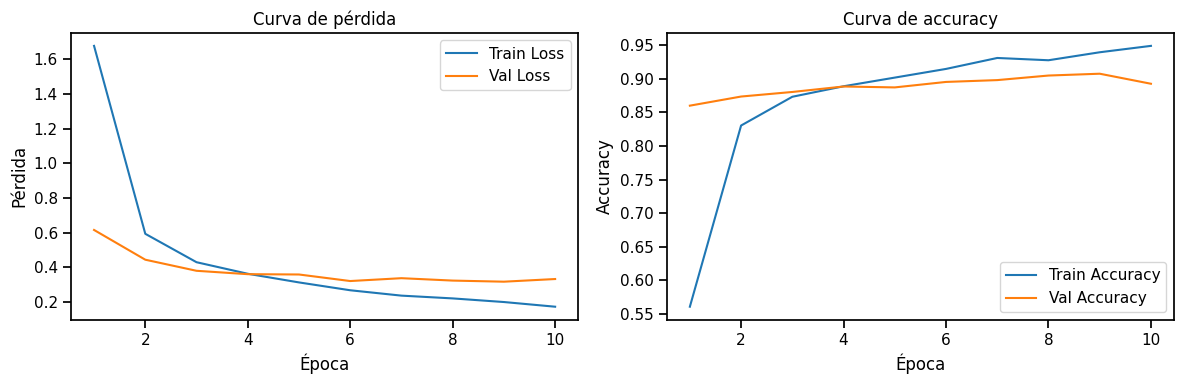

In [14]:
def plot_training_history(history):
    history_dict = history.history
    epochs_range = range(1, len(history_dict["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_dict["loss"], label="Train Loss")
    plt.plot(epochs_range, history_dict["val_loss"], label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("Curva de pérdida")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_dict["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history_dict["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Curva de accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 15. Evaluación sobre test

Evaluamos el modelo final de esta etapa sobre el conjunto de prueba.

In [15]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8942 - loss: 0.3425
Test Loss: 0.3425
Test Accuracy: 0.8942


## 16. Predicciones sobre el conjunto de prueba

Generaremos predicciones para hacer un análisis más detallado del comportamiento del modelo.

In [16]:
y_true = []
y_pred = []
test_images_for_display = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
    test_images_for_display.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Número de ejemplos evaluados:", len(y_true))

Número de ejemplos evaluados: 3669


## 17. Reporte de clasificación

El siguiente reporte muestra, para cada clase:

- precision,
- recall,
- f1-score,
- support.

Dado que son 37 clases, el reporte es largo, pero muy útil para identificar dónde el modelo funciona mejor o peor.

In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
)

print(report)

                            precision    recall  f1-score   support

                Abyssinian      0.897     0.888     0.892        98
          american_bulldog      0.623     0.960     0.756       100
 american_pit_bull_terrier      0.885     0.460     0.605       100
              basset_hound      0.958     0.920     0.939       100
                    beagle      0.904     0.940     0.922       100
                    Bengal      0.812     0.780     0.796       100
                    Birman      0.755     0.830     0.790       100
                    Bombay      0.917     0.875     0.895        88
                     boxer      0.863     0.889     0.876        99
         British_Shorthair      0.725     0.870     0.791       100
                 chihuahua      0.926     0.870     0.897       100
              Egyptian_Mau      0.929     0.814     0.868        97
    english_cocker_spaniel      0.979     0.940     0.959       100
            english_setter      0.950     0.960

## 18. Matriz de confusión

La matriz de confusión permite ver qué razas se confunden con mayor frecuencia.

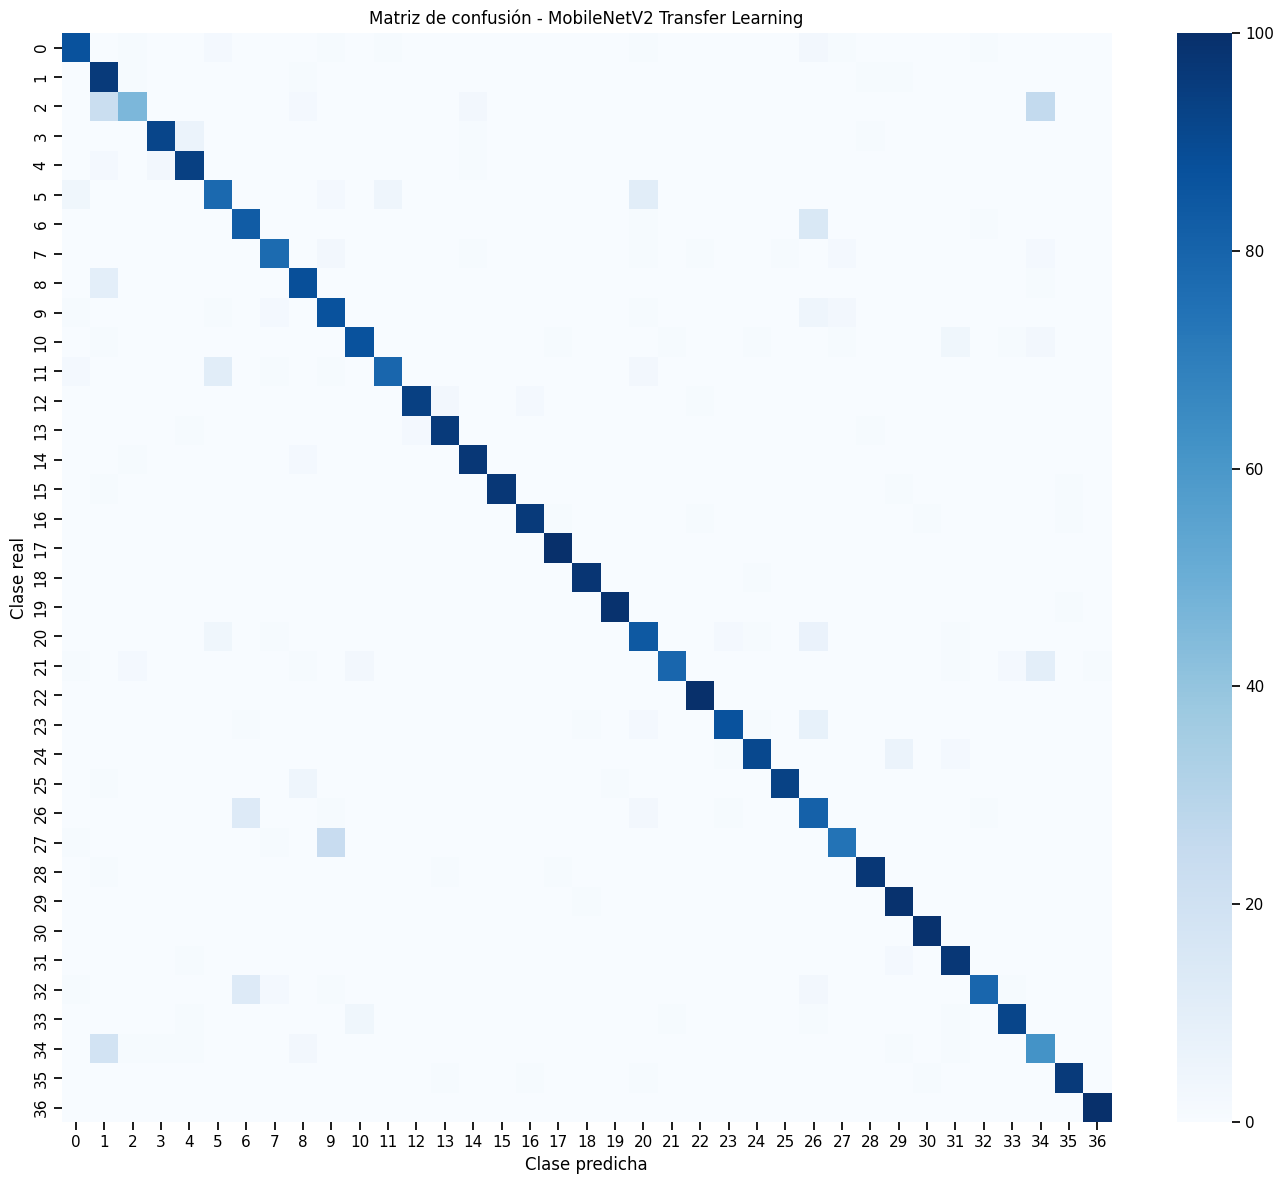

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Matriz de confusión - MobileNetV2 Transfer Learning")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

## 19. Visualización de predicciones

Mostramos algunos ejemplos con:
- clase real,
- clase predicha,
- color verde si la predicción es correcta,
- color rojo si es incorrecta.

Como las imágenes están en el rango preprocesado de MobileNetV2, las reescalamos solo para mostrarlas.

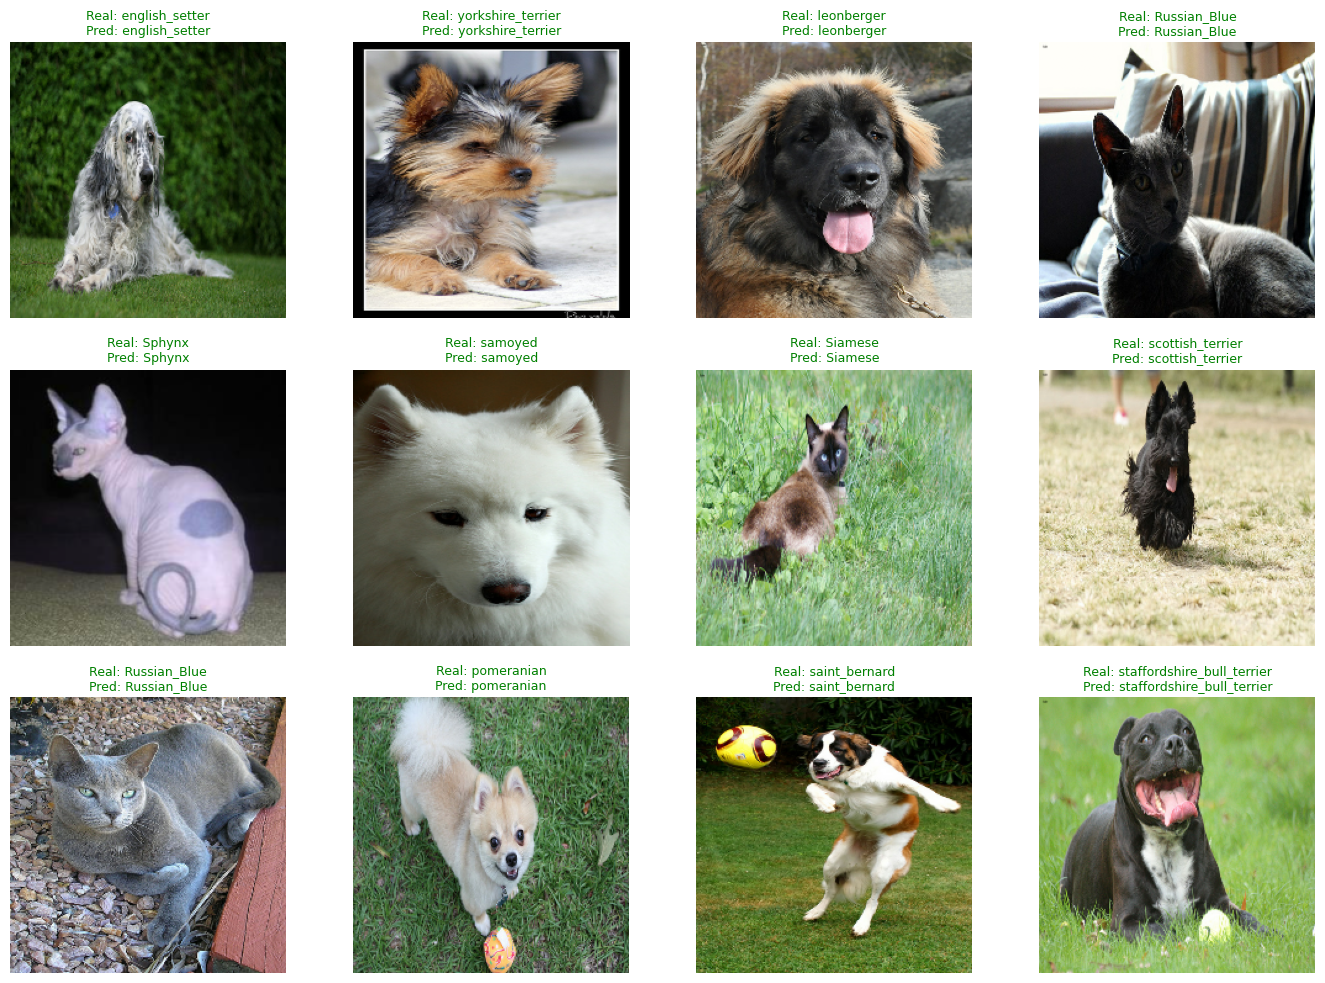

In [19]:
def show_predictions(images, y_true, y_pred, class_names, num_examples=12, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(images), size=num_examples, replace=False)

    plt.figure(figsize=(14, 10))
    for i, idx in enumerate(indices, 1):
        plt.subplot(3, 4, i)
        image = images[idx]
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        plt.imshow(image)

        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        correct = y_true[idx] == y_pred[idx]
        title_color = "green" if correct else "red"

        plt.title(f"Real: {true_label}\nPred: {pred_label}", color=title_color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(test_images_for_display, y_true, y_pred, class_names, num_examples=12)

## 20. Comentario sobre la comparación con la línea base

Este notebook representa una mejora metodológica frente al baseline porque:

1. reutiliza conocimiento visual aprendido en ImageNet,
2. reduce la necesidad de aprender todas las características desde cero,
3. suele converger más rápido,
4. normalmente logra mejor generalización.

### Qué se espera observar
En la mayoría de escenarios, el modelo de transfer learning debería:
- superar el accuracy del baseline,
- mostrar curvas de entrenamiento más estables,
- y cometer menos errores graves entre clases similares.

## 21. Conclusiones

En esta etapa se implementó un modelo de clasificación basado en **MobileNetV2 + transfer learning**:

- se cargó una red preentrenada,
- se congeló la base convolucional,
- se añadió una nueva cabeza para 37 clases,
- se entrenó la nueva cabeza,
- y se evaluó el modelo sobre el conjunto de prueba.

Esta versión constituye una solución más fuerte que la línea base y servirá como punto de partida para la etapa final de **fine-tuning**.